In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv("kenya.csv")

df["Country"] = "Kenya"

In [2]:
df["DATE"] = pd.to_datetime(df["YEAR"] * 1000 + df["DOY"], format="%Y%j")
df["Month"] = df["DATE"].dt.month

In [3]:
df = df.replace(-999, np.nan)

In [4]:
df.duplicated().sum()
df = df.drop_duplicates()

In [5]:
df.describe()
df.isna().sum()

YEAR           0
DOY            0
T2M            0
T2M_MAX        0
T2M_MIN        0
T2M_RANGE      0
PRECTOTCORR    0
RH2M           0
WS2M           0
WS2M_MAX       0
PS             0
QV2M           0
Country        0
DATE           0
Month          0
dtype: int64

In [6]:
from scipy.stats import zscore

cols = ["T2M","T2M_MAX","T2M_MIN","PRECTOTCORR","RH2M","WS2M","WS2M_MAX"]

z_scores = np.abs(df[cols].apply(zscore))

outliers = (z_scores > 3).sum()
outliers

T2M             8
T2M_MAX         3
T2M_MIN         9
PRECTOTCORR    92
RH2M            6
WS2M            0
WS2M_MAX        6
dtype: int64

In [7]:
df = df.ffill()
df = df.dropna(thresh=len(df.columns)*0.7)

In [8]:
import os

os.makedirs("data", exist_ok=True)
df.to_csv("data/ethiopia_clean.csv", index=False)

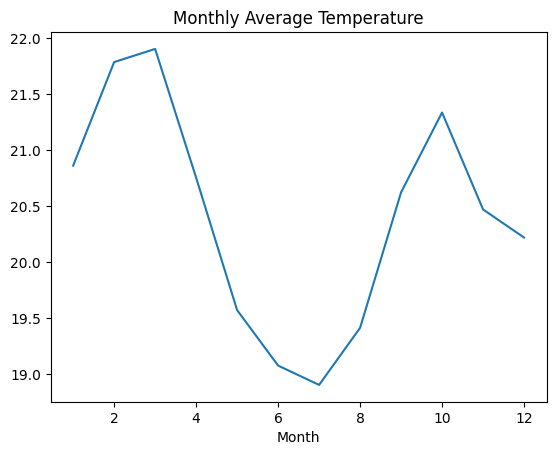

In [9]:
import matplotlib.pyplot as plt

monthly_temp = df.groupby("Month")["T2M"].mean()

monthly_temp.plot(kind="line")
plt.title("Monthly Average Temperature")
plt.show()

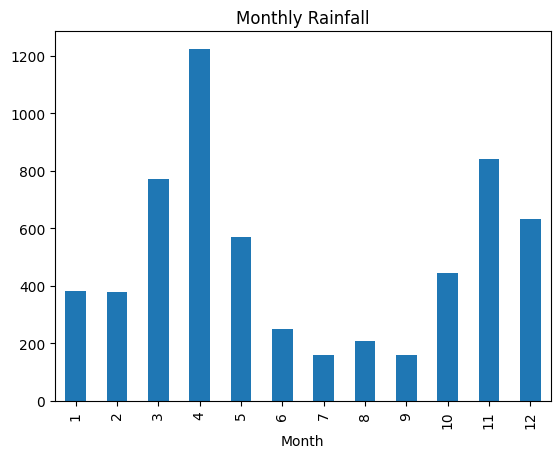

In [10]:
df.groupby("Month")["PRECTOTCORR"].sum().plot(kind="bar")
plt.title("Monthly Rainfall")
plt.show()

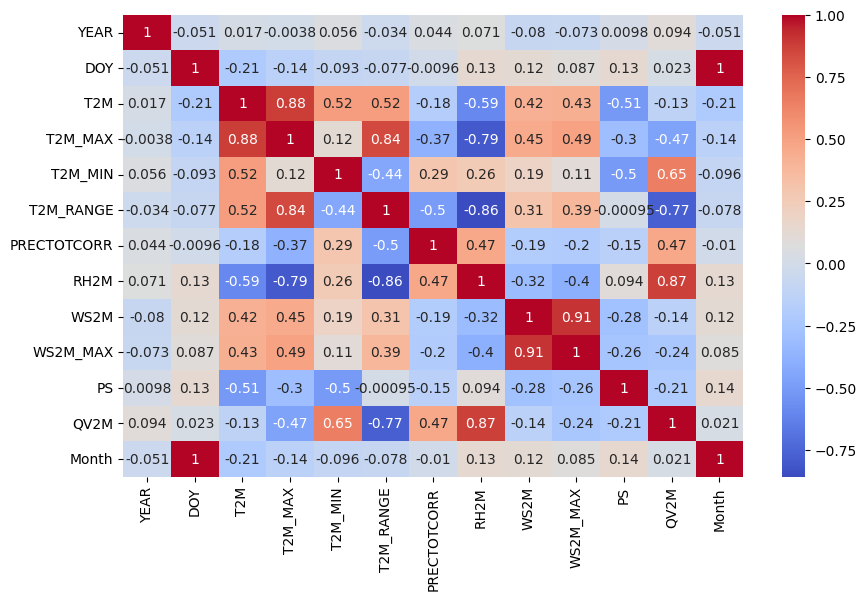

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

# use only numeric columns (important fix)
corr = df.select_dtypes(include='number').corr()

sns.heatmap(corr, annot=True, cmap="coolwarm")

plt.show()

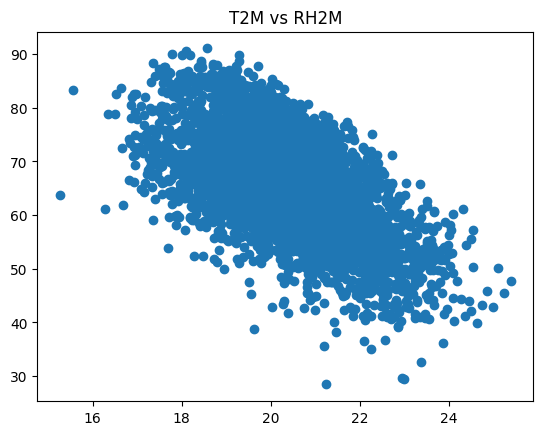

In [12]:
plt.scatter(df["T2M"], df["RH2M"])
plt.title("T2M vs RH2M")
plt.show()

## References & Self-Learning
To complete this analysis and meet the project KPIs, I performed independent research on the following topics:

* **NASA POWER Sentinel Values:** Consulted the [NASA POWER Documentation](https://power.larc.nasa.gov/docs/methodology/data-quality-assessment/) to confirm that `-999` is the official sentinel value for missing or out-of-range geophysical data.
* **Julian Date Parsing:** Researched the Python `datetime` strftime documentation to use the `%Y%j` format, which is necessary for converting "Year" and "Day of Year" columns into a single `datetime` object.
* **Statistical Outlier Methods:** Learned to apply `scipy.stats.zscore` to identify climate data points that deviate by more than 3 standard deviations, which is a standard threshold for environmental data cleaning.
* **Seaborn Plot Customization:** Self-taught the use of the `coolwarm` colormap and `annot=True` parameters in Seaborn heatmaps to make climate correlation matrices more readable for stakeholders.
* **Environment Management:** Utilized Python virtual environments (`.venv`) and `.gitignore` configurations to ensure a professional, clean repository structure as required by the task.